<a href="https://colab.research.google.com/github/adiknur007/ML/blob/main/%D0%A1%D3%A8%D0%96_20%D0%9D%D2%B1%D1%80%D1%82%D0%B0%D0%B5%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Кескінді өңдеу және сегментация

**Мақсаты:** Кескіндерді өңдеудің негізгі әдістерін және сегментация алгоритмдерін тәжірибеде қолдану.

Бұл жұмыс компьютерлік көру (Computer Vision) тапсырмаларына және машиналық оқытудағы деректерді алдын ала өңдеу (preprocessing) кезеңдеріне кіріспе болып табылады. Төмендегі код ұяшықтарында қалып қойған бос орындарды толтырып, әр алгоритмнің жұмыс істеу принципін зерттеңіз.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Графиктердің фонын ақ түсті етіп баптау (академиялық стиль үшін)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

### [Markdown ұяшығы]

## Тапсырма 1: Кескінді жүктеу және сұр түске (Grayscale) айналдыру

**Мақсаты:** Кескінді оқу және оны бір арналы форматқа түрлендіру.

Кескіндер әдетте үш арнадан (RGB) тұрады, бұл есептеу күрделілігін арттырады. Кескінді сұр түске айналдыру ақпараттың негізгі құрылымын сақтай отырып, деректер көлемін азайтады. Бұл көптеген сегментация алгоритмдері үшін міндетті алғашқы қадам болып табылады.


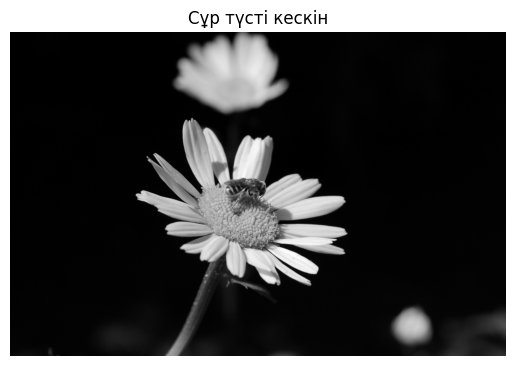

In [2]:
# Кескінді оқу (өз суретіңіздің жолын көрсетіңіз)
image = cv2.imread('sample_image.jpg')

# OpenCV кескіндерді BGR форматында оқиды, оны RGB-ге ауыстырамыз
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# TODO: cv2.cvtColor функциясын қолданып, кескінді сұр түске (Grayscale) айналдырыңыз
gray_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

# Нәтижені көрсету
plt.imshow(gray_image, cmap='gray')
plt.title('Сұр түсті кескін')
plt.axis('off')
plt.show()

## Тапсырма 2: Глобалды шектік сегментация (Thresholding)

**Мақсаты:** Пиксельдердің жарықтығына негізделген ең қарапайым сегментацияны орындау.

Шектік өңдеу (Thresholding) кескінді екілік (бинарлы) форматқа айналдырады. Белгілі бір шекті мәннен асып түсетін пиксельдер ақ түске, ал одан төмендері қара түске боялады. Бұл нысандарды фоннан бөліп алудың ең жылдам әрі тиімді әдісі.


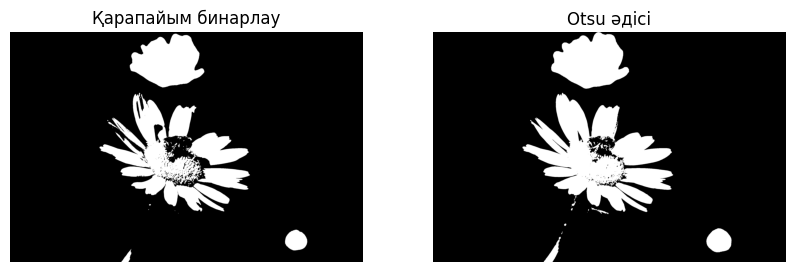

In [3]:
# TODO: cv2.threshold функциясын қолданып, глобалды бинарлауды орындаңыз (шекті мән ретінде 127 алыңыз)
ret, thresh_image = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)

# TODO: Otsu әдісі арқылы автоматты түрде шекті мәнді табатын бинарлауды орындаңыз
ret_otsu, thresh_otsu = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Нәтижелерді көрсету
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(thresh_image, cmap='gray')
axes[0].set_title('Қарапайым бинарлау')
axes[0].axis('off')

axes[1].imshow(thresh_otsu, cmap='gray')
axes[1].set_title('Otsu әдісі')
axes[1].axis('off')
plt.show()

## Тапсырма 3: Canny әдісімен шеттерді анықтау (Edge Detection)

**Мақсаты:** Кескіндегі нысандардың шекараларын табу.

Canny алгоритмі кескіндегі интенсивтіліктің күрт өзгеретін аймақтарын іздейді. Ол шуды азайту, градиенттерді есептеу және жалған шеттерді алып тастау сияқты бірнеше кезеңнен тұрады. Бұл әдіс нысандардың пішінін анықтауда өте дәл нәтиже береді.


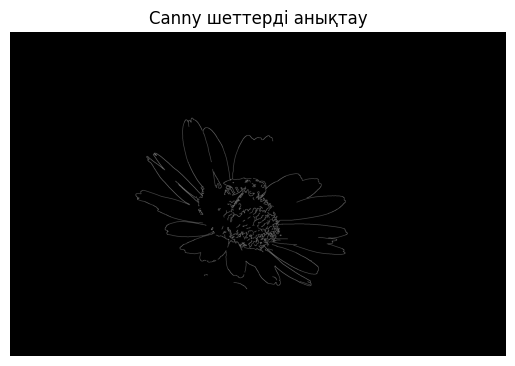

In [14]:
# TODO: Шуды азайту үшін кескінді бұлыңғырлаңыз (мысалы, cv2.GaussianBlur қолданыңыз)
blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)

# TODO: Бұлыңғырланған кескінге cv2.Canny алгоритмін қолданыңыз (шектерді 100 және 200 деп алыңыз)
edges = cv2.Canny(blurred_image, 100, 200)

# Шеттерді бейнелеу
plt.imshow(edges, cmap='gray')
plt.title('Canny шеттерді анықтау')
plt.axis('off')
plt.show()

## Тапсырма 4: K-Means кластерлеу арқылы түстерге негізделген сегментация

**Мақсаты:** Түстердің ұқсастығы бойынша кескінді бірнеше аймақтарға бөлу.

K-Means алгоритмі бақылаусыз оқыту (unsupervised learning) әдісіне жатады. Ол кескіндегі барлық пиксельдерді олардың түс мәндеріне қарай алдын ала берілген K кластерге біріктіреді. Бұл әдіс күрделі фондарды сегментациялауда және бейненің түстік палитрасын азайтуда кеңінен қолданылады.


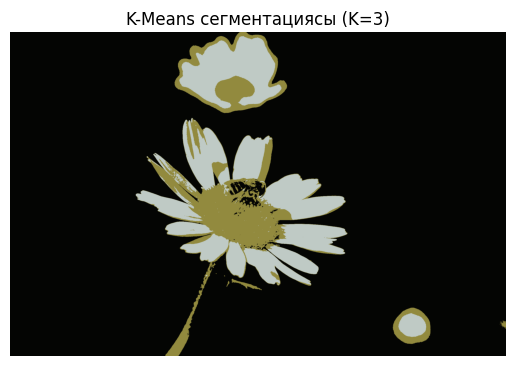

In [9]:
# Кескінді 2D массивке түрлендіру
pixel_values = image_rgb.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

# K-Means алгоритмінің тоқтау шарттарын анықтау
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

# Кластерлер саны
k = 3

# TODO: cv2.kmeans функциясын қолданып, пиксельдерді k кластерге бөліңіз
_, labels, (centers) = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

# Орталықтарды 8-биттік мәндерге қайтару
centers = np.uint8(centers)

# Барлық пиксельдерді орталықтардың түстерімен ауыстыру
segmented_image = centers[labels.flatten()]

# TODO: Сегменттелген кескінді бастапқы image_rgb өлшеміне (shape) қайта түріндеңіз (reshape)
segmented_image = segmented_image.reshape(image_rgb.shape)
# Сегменттелген кескінді көрсету
plt.imshow(segmented_image)
plt.title(f'K-Means сегментациясы (K={k})')
plt.axis('off')
plt.show()

## Тапсырма 5: Контурларды табу және оларды сызу

**Мақсаты:** Бинарлы кескіннен нысандардың шекараларын тауып, оларды бөлектеп көрсету.

Контурларды іздеу алгоритмі бірдей жарықтығы бар барлық тұтас нүктелерді байланыстырады. Ол пішінді талдау және нысандарды тану үшін өте маңызды. Әдетте бұл әдіс бинарланған немесе шеттері анықталған кескіндерге қолданылады.


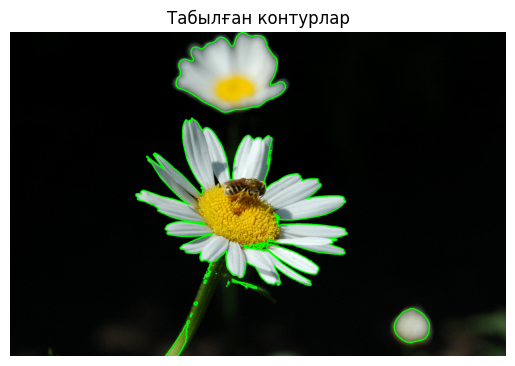

In [15]:
# TODO: cv2.findContours функциясын пайдаланып, thresh_otsu кескінінен контурларды табыңыз
contours, hierarchy = cv2.findContours(thresh_otsu, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Түпнұсқа кескіннің көшірмесін жасау
contour_image = image_rgb.copy()

# TODO: cv2.drawContours арқылы табылған контурларды contour_image бетіне жасыл түспен сызыңыз
cv2.drawContours(contour_image, contours, -1, (0, 255, 0), 6)

# Нәтижені бейнелеу
plt.imshow(contour_image)
plt.title('Табылған контурлар')
plt.axis('off')
plt.show()

## Тапсырма 6: Шығармашылық тапсырма (Дербес жұмыс)

Мақсаты: Алдыңғы тапсырмалардағы әдістерді біріктіріп, нақты қолданбалы есепті шешу және алынған деректерді талдау.

Компьютерлік көрудің нақты жобаларында (мысалы, смарт қалалардағы бейнебақылау камераларынан деректер алу немесе медициналық суреттерді талдау) көбінесе бір ғана алгоритм жеткіліксіз болады. Бұл тапсырмада сіз өзіңіздің жеке кескініңізді таңдап, оны кешенді түрде өңдеуіңіз қажет.

Сіздің міндетіңіз: кескіндегі біртектес нысандарды табу және санау (мысалы, тиындарды, көліктерді немесе жасушаларды). Ол үшін бинарлау, шуды азайту және контурларды іздеу әдістерін біріктіріңіз. Нәтижелерді визуалдау кезінде алдыңғы тапсырмалардағыдай академиялық стильді (ақ фон, анық әрі қысқа тақырыптар) сақтауды ұмытпаңыз.

In [ ]:
# 1. Өзіңіз таңдаған күрделі кескінді жүктеңіз

# 2. Деректерді алдын ала өңдеу (кескінді сұр түске айналдыру және GaussianBlur арқылы шуды азайту)

# 3. Сегментациялау әдістерін қолдану (мысалы, Canny шеттерін анықтау немесе Otsu бинарлауы)

# 4. Контурларды табу және олардың санын есептеу (осы арқылы нысандар санын шығарыңыз)

# 5. Нәтижені академиялық стильде визуалдау
